# Pore Graph Construction for MOFs

step by step created while working on it/figuring it out myself


## Imports and setup

In [3]:
import sys, os, tempfile
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist
from sklearn.cluster import DBSCAN
import torch
import dgl

sys.path.insert(0, '/home/milan/Downloads/alignn')
sys.path.insert(0, '/home/milan/Downloads/alignn/Thesis/Pore_plan_b')

from jarvis.db.figshare import data as jdata
from jarvis.core.atoms import Atoms
from pyzeo.netstorage import AtomNetwork

print('All imports OK')
print(f'PyTorch: {torch.__version__}')
print(f'DGL: {dgl.__version__}')

All imports OK
PyTorch: 2.2.1+cu121
DGL: 1.1.1



##  Load one MOF structure

We load the first one (hMOF-3476) to use as an example.

hMOF-3476 has:
- 123 atoms in its unit cell
- Elements: Zn, C, H, N, O
- Unit cell dimensions: ~19 x 21 x 21 Angstrom
- Unit cell volume: ~8718 Angstrom^3

For comparison, a single carbon atom has a radius of about 1.7 Angstrom,
so this unit cell is quite large, typical of MOFs which are engineered to have large internal pores.

In [4]:
print('Loading hMOF dataset...')
raw = jdata('hmof')
print(f'Dataset loaded: {len(raw)} structures')

entry = raw[0]
atoms = Atoms.from_dict(entry['atoms'])
lat = atoms.lattice_mat
volume = float(np.linalg.det(lat))

print(f'\nStructure: {entry["id"]}')
print(f'Number of atoms: {len(atoms.elements)}')
print(f'Elements present: {set(atoms.elements)}')
print(f'Unit cell dimensions:')
print(f'  a = {lat[0][0]:.2f} Angstrom')
print(f'  b = {lat[1][1]:.2f} Angstrom')
print(f'  c = {lat[2][2]:.2f} Angstrom')
print(f'Unit cell volume: {volume:.1f} Angstrom^3')
print(f'\nTarget values we want to predict:')
print(f'  Surface area (m2/g):   {entry["surface_area_m2g"]:.1f}')
print(f'  Surface area (m2/cm3): {entry["surface_area_m2cm3"]:.1f}')
print(f'  Void fraction:         {entry["void_fraction"]:.3f}')
print(f'  Largest cavity (LCD):  {entry["lcd"]:.2f} Angstrom')
print(f'  Pore limiting dia(PLD):{entry["pld"]:.2f} Angstrom')

Loading hMOF dataset...
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
Dataset loaded: 137652 structures

Structure: hMOF-3476
Number of atoms: 123
Elements present: {'C', 'H', 'O', 'N', 'Zn'}
Unit cell dimensions:
  a = 19.08 Angstrom
  b = 21.38 Angstrom
  c = 21.38 Angstrom
Unit cell volume: 8718.5 Angstrom^3

Target values we want to predict:
  Surface area (m2/g):   5173.4
  Surface area (m2/cm3): 1444.8
  Void fraction:         0.892
  Largest cavity (LCD):  20.75 Angstrom
  Pore limiting dia(PLD):19.25 Angstrom


---
## Voronoi decomposition

Each Voronoi node is equidistant from its nearest atoms, so it sits in the middle of the void space.
The distance from a Voronoi node to its nearest atom is the pore radius at that point, 
this tells you the radius of the largest sphere that fits at that location.


## Run Voronoi decomposition with pyzeo

We use pyzeo (Python interface to Zeo++) to perform the Voronoi decomposition.

### Discoverings about the pyzeo API

Getting pyzeo to work required some reverse engineering (trial and error). Key findings:
- read_from_CIF fails, pyzeo 0.1.7 cannot parse CIF files reliably
- read_from_CSSR works, but requires the file path as bytes (.encode()), not a string
- Atomic radii must be supplied via a separate .rad file. Without them, all radii are 0
- Voronoi nodes come back as plain (x, y, z) tuples in coordinates
- Pore radii are NOT in the tuples, you get them from `write_to_XYZ`

The CSSR format is Zeo++'s native format, simpler than CIF. We write it manually from the jarvis Atoms object.

In [5]:
# Van der Waals radii
# Only elements present in the hMOF dataset
RADII = {
    'H':  1.20, 'C':  1.77, 'N':  1.66, 'O':  1.50,
    'F':  1.46, 'Al': 2.25, 'Si': 2.19, 'P':  1.90,
    'S':  1.89, 'Cl': 1.82, 'Br': 1.86, 'Zn': 2.39,
    'Cu': 2.38, 'Co': 2.40, 'Ni': 2.40, 'Fe': 2.44,
    'Mn': 2.45, 'Cr': 2.45, 'V':  2.42, 'Ti': 2.46,
    'Cd': 2.49, 'Zr': 2.52, 'Mo': 2.45, 'In': 2.43,
}

def atoms_to_cssr(atoms, path):
    """Write a jarvis Atoms object to CSSR format for pyzeo."""
    lat = atoms.lattice_mat
    elements = atoms.elements
    coords = atoms.frac_coords
    a, b, c = lat[0][0], lat[1][1], lat[2][2]
    with open(path, 'w') as f:
        f.write(f'                {a:.4f}  {b:.4f}  {c:.4f}\n')
        f.write(f'   90.0000   90.0000   90.0000   SPGR =  1 P 1\n')
        f.write(f' {len(elements)} 0\n')
        f.write(f' 0 {atoms.composition.formula}\n')
        for i, (el, fc) in enumerate(zip(elements, coords)):
            f.write(f'{i+1} {el} {fc[0]:.6f} {fc[1]:.6f} {fc[2]:.6f}  0  0  0  0  0  0  0  0 0.000\n')

def write_rad_file(atoms, path):
    """Write radii file: each element and its van der Waals radius."""
    with open(path, 'w') as f:
        for el in set(atoms.elements):
            f.write(f'{el} {RADII.get(el, 1.5)}\n')

# Write temporary files
with tempfile.NamedTemporaryFile(suffix='.cssr', delete=False, mode='w') as tmp:
    cssr_path = tmp.name
rad_path = cssr_path.replace('.cssr', '.rad')
xyz_path = cssr_path.replace('.cssr', '.xyz')

atoms_to_cssr(atoms, cssr_path)
write_rad_file(atoms, rad_path)

print('Files written:')
print(f'  CSSR: {cssr_path} ({os.path.getsize(cssr_path)} bytes)')
print(f'  RAD:  {rad_path} ({os.path.getsize(rad_path)} bytes)')
print(f'\nFirst 5 lines of CSSR file:')
with open(cssr_path) as f:
    for i, line in enumerate(f):
        if i >= 5: break
        print(f'  {line}', end='')
print(f'\n\nContents of radii file:')
print(open(rad_path).read())

Files written:
  CSSR: /tmp/tmp4n8dsncy.cssr (7759 bytes)
  RAD:  /tmp/tmp4n8dsncy.rad (34 bytes)

First 5 lines of CSSR file:
                  19.0771  21.3784  21.3775
     90.0000   90.0000   90.0000   SPGR =  1 P 1
   123 0
   0 O31N2H32Zn4C54
  1 O 0.338843 0.685724 0.893334  0  0  0  0  0  0  0  0 0.000


Contents of radii file:
C 1.77
H 1.2
O 1.5
N 1.66
Zn 2.39



In [6]:
# Run Voronoi decomposition
# NOTE: path must be passed as bytes (.encode()) -- pyzeo 0.1.7 quirk
print('Running Voronoi decomposition...')
atm_ntw = AtomNetwork.read_from_CSSR(
    cssr_path.encode(),         # bytes, not string
    rad_flag=True,              # use atomic radii
    rad_file=rad_path.encode()  # path to .rad file
)

# Returns three things:
#   vornet =  VoronoiNetwork object
#   bef    = ALL Voronoi nodes (before filtering)
#   aft    = nodes after high-accuracy filtering
vornet, bef, aft = atm_ntw.perform_voronoi_decomposition()

print(f'\nVoronoi decomposition complete!')
print(f'  Total Voronoi nodes: {len(bef)}')
print(f'  Voronoi edges: {vornet.size()}')
print(f'\nEach node is a (x, y, z) tuple in Cartesian coordinates (Angstrom)')
print(f'First 3 nodes:')
for i, node in enumerate(bef[:3]):
    print(f'  node {i}: ({node[0]:.3f}, {node[1]:.3f}, {node[2]:.3f})')

Running Voronoi decomposition...
True b'/tmp/tmp4n8dsncy.rad'
Reading input file: /tmp/tmp4n8dsncy.cssr

Voronoi decomposition complete!
  Total Voronoi nodes: 1517
  Voronoi edges: 750

Each node is a (x, y, z) tuple in Cartesian coordinates (Angstrom)
First 3 nodes:
  node 0: (17.167, 11.113, 5.984)
  node 1: (16.024, 1.772, 7.278)
  node 2: (16.272, 1.581, 3.612)
Box dimensions:
  va=(19.077100 0 0)
  vb=(0.000000 21.378400 0)
  vc=(0.000000 0.000000 21.377500)

Total particles = 123

Internal grid size = (3 3 3)

Using voro++ with radii for particles.
Performing Voronoi decomposition.
Volume check:
  Total domain volume  = 8718.554165
  Total Voronoi volume = 8718.554165
Voronoi decomposition finished. Rerouting Voronoi network information.
Finished rerouting information.


---
## Get pore radii from write_to_XYZ

The Voronoi nodes only give us positions (x, y, z). We also need the **pore radius** at each node.

Pyzeo's write_to_XYZ writes all accessible pore nodes to a file in this format:

614          <- number of accessible nodes

X  x  y  z  radius   <- one line per node
...

This is better than computing distances manually, pyzeo already did the filtering,
giving 614 nodes instead of the original 1511.

In [7]:
PROBE_RADIUS = 1.2  # Angstrom, radius of CO2 probe molecule

# write_to_XYZ filters to nodes accessible by the probe molecule
vornet.write_to_XYZ(xyz_path, PROBE_RADIUS)

# Parse the output file
with open(xyz_path) as f:
    lines = f.readlines()

n_nodes = int(lines[0].strip()) # first line = "593"
nodes = []
for line in lines[2:2+n_nodes]: # skip line 0 (count) and line 1 (blank)
    parts = line.split() # splits "X  16.407  1.102  6.632  8.147" by whitespace
    x, y, z, r = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
    nodes.append((x, y, z, r))

positions = np.array([[n[0], n[1], n[2]] for n in nodes]) # shape (593, 3)
radii = np.array([n[3] for n in nodes]) # shape (593,)

print(f'Accessible pore nodes: {len(nodes)}')
print(f'(filtered from {len(bef)} total using probe radius {PROBE_RADIUS} Angstrom)')
print(f'\nPore radius statistics:')
print(f'  Minimum: {radii.min():.2f} Angstrom')
print(f'  Maximum: {radii.max():.2f} Angstrom  <-- this is approximately LCD/2')
print(f'  Mean:    {radii.mean():.2f} Angstrom')
print(f'  Median:  {np.median(radii):.2f} Angstrom')
print(f'\nFor reference, LCD from dataset: {entry["lcd"]:.2f} Angstrom')

# Clean up
for p in [cssr_path, rad_path, xyz_path]:
    if os.path.exists(p): os.unlink(p)

Writing Voronoi network information to /tmp/tmp4n8dsncy.xyz
Accessible pore nodes: 593
(filtered from 1517 total using probe radius 1.2 Angstrom)

Pore radius statistics:
  Minimum: 1.21 Angstrom
  Maximum: 10.42 Angstrom  <-- this is approximately LCD/2
  Mean:    4.21 Angstrom
  Median:  3.46 Angstrom

For reference, LCD from dataset: 20.75 Angstrom


---
## DBSCAN: OLD VERSION, this is not used anymore!!!

614 nodes is too many. Voronoi decomposition places nodes everywhere in the void space,
including hundreds of nodes clustered inside the same physical pore.

Think of it like this:
```
One physical pore:          Many Voronoi nodes inside it:

   ___________                  ___________
  /           \                / . . . . . \
 |             |              | . . . . . . |
 |    void     |    -->       | . . . . . . |
 |             |              | . . . . . . |
  \___________/                \. . . . . ./
```

For a GNN we want one node per distinct pore, not hundreds of redundant nodes.
We solve this with DBSCAN clustering, a simple algorithm that groups nearby points.

### What DBSCAN does
- Groups all nodes within 3 Angstrom of each other into the same cluster
- Each cluster = one physical pore region
- We keep the node with the largest radius per cluster (widest point = most representative)

In [8]:
CLUSTER_EPS = 3.0  # Angstrom -- nodes within this distance are the same pore

clustering = DBSCAN(eps=CLUSTER_EPS, min_samples=1).fit(positions)
labels = clustering.labels_
n_clusters = len(set(labels))

print(f'DBSCAN clustering with eps={CLUSTER_EPS} Angstrom:')
print(f'  Input nodes:  {len(nodes)}')
print(f'  Output clusters (distinct pores): {n_clusters}')
print(f'  Compression ratio: {len(nodes)/n_clusters:.0f}x')

cluster_positions = []
cluster_radii = []
cluster_sizes = []

for c in range(n_clusters):
    mask = labels == c
    idx = np.where(mask)[0]
    best = idx[radii[idx].argmax()]  # node with largest radius in cluster
    cluster_positions.append(positions[best])
    cluster_radii.append(radii[best])
    cluster_sizes.append(mask.sum())

cluster_positions = np.array(cluster_positions)
cluster_radii = np.array(cluster_radii)

print(f'\nThe {n_clusters} distinct pores:')
print(f'{"Pore":>5} {"Radius":>10} {"Position (x,y,z)":>35} {"Nodes merged":>12}')
print('-' * 68)
for i in range(n_clusters):
    pos = cluster_positions[i]
    r = cluster_radii[i]
    sz = cluster_sizes[i]
    pos_str = f'({pos[0]:.1f}, {pos[1]:.1f}, {pos[2]:.1f})'
    print(f'{i:>5} {r:>9.2f} A {pos_str:>35} {sz:>12}')

DBSCAN clustering with eps=3.0 Angstrom:
  Input nodes:  593
  Output clusters (distinct pores): 11
  Compression ratio: 54x

The 11 distinct pores:
 Pore     Radius                    Position (x,y,z) Nodes merged
--------------------------------------------------------------------
    0     10.42 A                    (16.0, 4.1, 8.9)          539
    1      6.17 A                   (17.9, 21.1, 5.3)            3
    2      3.50 A                     (2.0, 4.4, 2.3)            5
    3      7.01 A                   (16.8, 0.6, 14.3)            8
    4      6.36 A                   (16.1, 6.4, 21.3)            5
    5      4.92 A                    (0.2, 11.3, 9.1)            3
    6      4.00 A                   (12.3, 8.8, 21.2)           24
    7      2.68 A                  (12.1, 10.0, 14.5)            2
    8      5.32 A                  (11.4, 21.0, 11.4)            1
    9      4.27 A                   (14.0, 6.9, 17.9)            2
   10      1.80 A                   (11.2, 5.4

---
## Build edges between pores

Now we have 11 pore nodes. We connect them with edges when they are within a cutoff distance.

We use 8 Angstrom, the same as ALIGNN's atom graph cutoff. Two pores within 8 Angstrom
are physically close enough to be connected by a channel.

The edge feature is the distance between the two pore centers.

In [9]:
print('Edge density at different cutoffs:')
print(f'{"Cutoff":>10} {"Edges":>8} {"Avg edges/node":>16}')
print('-' * 36)

D = cdist(cluster_positions, cluster_positions)
for cutoff in [5.0, 6.0, 7.0, 8.0, 10.0, 12.0]:
    src, dst = np.where((D < cutoff) & (D > 0))
    print(f'{cutoff:>9.1f} A {len(src):>8} {len(src)/n_clusters:>16.1f}')

EDGE_CUTOFF = 8.0
src_idx, dst_idx = np.where((D < EDGE_CUTOFF) & (D > 0))
edge_distances = D[src_idx, dst_idx]

print(f'\nUsing cutoff = {EDGE_CUTOFF} Angstrom')
print(f'Edges: {len(src_idx)} ({len(src_idx)//2} unique pairs)')
print(f'\nEdge list (src --> dst, distance, pore radii):')
seen = set()
for s, d, dist in zip(src_idx, dst_idx, edge_distances):
    if (d, s) not in seen:
        seen.add((s, d))
        print(f'  pore {s:2d} --> pore {d:2d}   dist={dist:.2f} A   '
              f'radii=({cluster_radii[s]:.1f}, {cluster_radii[d]:.1f})')

Edge density at different cutoffs:
    Cutoff    Edges   Avg edges/node
------------------------------------
      5.0 A        8              0.7
      6.0 A       14              1.3
      7.0 A       20              1.8
      8.0 A       24              2.2
     10.0 A       38              3.5
     12.0 A       44              4.0

Using cutoff = 8.0 Angstrom
Edges: 24 (12 unique pairs)

Edge list (src --> dst, distance, pore radii):
  pore  0 --> pore  3   dist=6.45 A   radii=(10.4, 7.0)
  pore  3 --> pore  9   dist=7.77 A   radii=(7.0, 4.3)
  pore  3 --> pore 10   dist=7.80 A   radii=(7.0, 1.8)
  pore  4 --> pore  6   dist=4.50 A   radii=(6.4, 4.0)
  pore  4 --> pore  9   dist=3.99 A   radii=(6.4, 4.3)
  pore  4 --> pore 10   dist=6.56 A   radii=(6.4, 1.8)
  pore  6 --> pore  7   dist=6.81 A   radii=(4.0, 2.7)
  pore  6 --> pore  9   dist=4.14 A   radii=(4.0, 4.3)
  pore  6 --> pore 10   dist=5.47 A   radii=(4.0, 1.8)
  pore  7 --> pore  9   dist=5.03 A   radii=(2.7, 4.3)
  pore 

---
## Build the DGL pore graph

Now we build a DGL (Deep Graph Library) graph, the same format ALIGNN uses for its atom graph.
This means we can plug it directly into the ALIGNN pipeline.

### Node features
Pore radius (1 value per node). In a more advanced version this can be
RBF-expanded, same is for edge features, (encoded as a vector of Gaussian values) to give the GNN a richer representation.

### Edge features
Distance between connected pores (1 value per edge).

In [10]:
P = dgl.graph((src_idx.tolist(), dst_idx.tolist()))

# Node features: pore radius
P.ndata['h'] = torch.tensor(cluster_radii, dtype=torch.float32).unsqueeze(1)

# Edge features: distance between pores
P.edata['h'] = torch.tensor(edge_distances, dtype=torch.float32).unsqueeze(1)

print('DGL Pore Graph P:')
print(f'  Nodes: {P.num_nodes()}')
print(f'  Edges: {P.num_edges()}')
print(f'  Node feature shape: {P.ndata["h"].shape}  (n_nodes x 1)')
print(f'  Edge feature shape: {P.edata["h"].shape}  (n_edges x 1)')
print(f'\nNode features (pore radii in Angstrom):')
print(f'  {[round(x,2) for x in P.ndata["h"].squeeze().tolist()]}')
print(f'\nValid DGL graph -- ready for GNN message passing')
print(f'\nFor comparison, the atom graph for this structure has:')
print(f'  123 atom nodes  vs  {P.num_nodes()} pore nodes')
print(f'  The pore graph is much smaller but captures void space topology')

DGL Pore Graph P:
  Nodes: 11
  Edges: 24
  Node feature shape: torch.Size([11, 1])  (n_nodes x 1)
  Edge feature shape: torch.Size([24, 1])  (n_edges x 1)

Node features (pore radii in Angstrom):
  [10.42, 6.17, 3.5, 7.01, 6.36, 4.92, 4.0, 2.68, 5.32, 4.27, 1.8]

Valid DGL graph -- ready for GNN message passing

For comparison, the atom graph for this structure has:
  123 atom nodes  vs  11 pore nodes
  The pore graph is much smaller but captures void space topology


---
## Visualize the pore graph

Each node is drawn as a circle:
- Size = pore radius (bigger = larger pore)
- Color = pore radius (yellow = large, purple = small)
- Lines = edges (connections between adjacent pores)

This is the visualization recommended before building any ML model

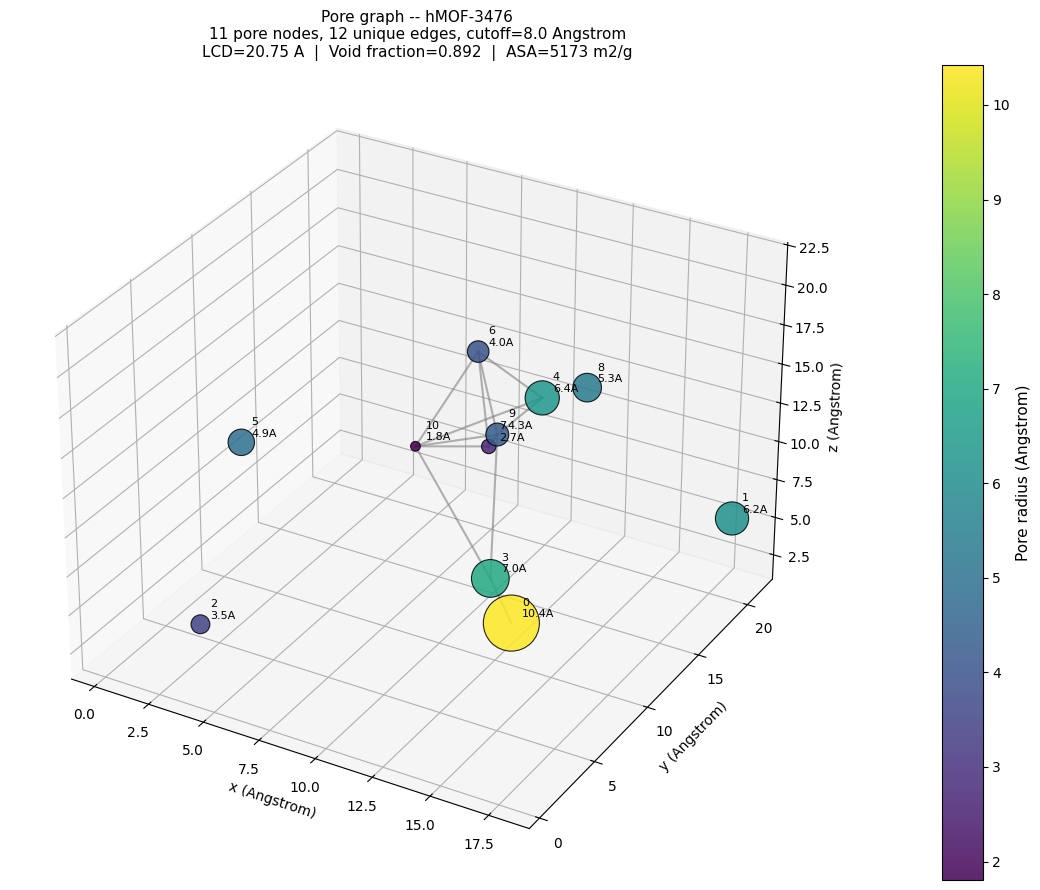

Saved to: /home/milan/Downloads/alignn/Thesis/Pore_plan_b/pore_graph_tutorial.png


In [11]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Draw edges first (nodes appear on top)
seen = set()
for s, d in zip(src_idx, dst_idx):
    if (d, s) not in seen:
        seen.add((s, d))
        xs = [cluster_positions[s][0], cluster_positions[d][0]]
        ys = [cluster_positions[s][1], cluster_positions[d][1]]
        zs = [cluster_positions[s][2], cluster_positions[d][2]]
        ax.plot(xs, ys, zs, color='gray', alpha=0.6, linewidth=1.5)

# Draw nodes sized and colored by pore radius
sc = ax.scatter(
    cluster_positions[:, 0],
    cluster_positions[:, 1],
    cluster_positions[:, 2],
    s=cluster_radii ** 2 * 15,
    c=cluster_radii,
    cmap='viridis',
    alpha=0.85,
    edgecolors='black',
    linewidths=0.8,
    zorder=5
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('Pore radius (Angstrom)', fontsize=11)

# Label each node
for i, (pos, r) in enumerate(zip(cluster_positions, cluster_radii)):
    ax.text(pos[0]+0.3, pos[1]+0.3, pos[2]+0.3, f'{i}\n{r:.1f}A', fontsize=8)

ax.set_xlabel('x (Angstrom)', fontsize=10)
ax.set_ylabel('y (Angstrom)', fontsize=10)
ax.set_zlabel('z (Angstrom)', fontsize=10)
ax.set_title(
    f'Pore graph -- {entry["id"]}\n'
    f'{n_clusters} pore nodes, {len(seen)} unique edges, cutoff={EDGE_CUTOFF} Angstrom\n'
    f'LCD={entry["lcd"]:.2f} A  |  '
    f'Void fraction={entry["void_fraction"]:.3f}  |  '
    f'ASA={entry["surface_area_m2g"]:.0f} m2/g',
    fontsize=11
)

plt.tight_layout()
save_path = '/home/milan/Downloads/alignn/Thesis/Pore_plan_b/pore_graph_tutorial.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to: {save_path}')

## Link to the actual mof:

https://mof.tech.northwestern.edu/mofs/18812



## Fix the problem with 2 pores representing 1 cavity.

Removed parts and figures not used in paper

In [12]:
import numpy as np
dist = np.linalg.norm(cluster_positions[0] - cluster_positions[3])
print(f"Distance between node 0 and node 3: {dist:.2f} Angstrom")
print(f"Node 0 radius: {cluster_radii[0]:.2f} Angstrom")
print(f"Node 3 radius: {cluster_radii[3]:.2f} Angstrom")
print(f"Sum of radii: {cluster_radii[0] + cluster_radii[3]:.2f} Angstrom")
print(f"Do they overlap? {dist < cluster_radii[0] + cluster_radii[3]}")

Distance between node 0 and node 3: 6.45 Angstrom
Node 0 radius: 10.42 Angstrom
Node 3 radius: 7.01 Angstrom
Sum of radii: 17.43 Angstrom
Do they overlap? True


In [13]:
from sklearn.cluster import DBSCAN
import numpy as np

# Try different eps values
for eps in [3.0, 5.0, 8.0, 10.0, 12.0]:
    clustering = DBSCAN(eps=eps, min_samples=1).fit(positions)
    n = len(set(clustering.labels_))
    print(f"eps={eps:5.1f}A --> {n:3d} clusters")

eps=  3.0A -->  11 clusters
eps=  5.0A -->   2 clusters
eps=  8.0A -->   1 clusters
eps= 10.0A -->   1 clusters
eps= 12.0A -->   1 clusters


## Solution, Radius aware clusterin.

In [14]:
from collections import defaultdict
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

# Radius-aware clustering function
def radius_aware_clustering(positions, radii):
    """Merge nodes where one sits inside the other's sphere.
    
    Two nodes are the same pore if:
        distance(i, j) < max(radius_i, radius_j)
    
    We keep the node with the largest radius per cluster.
    Uses Union-Find for efficient grouping.
    """
    n = len(positions)
    if n == 0:
        return positions, radii

    # Step 1: compute all pairwise distances
    D = cdist(positions, positions)          # shape (N, N)

    # Step 2: for each pair, check if one sits inside the other
    # R_max[i,j] = the larger of the two radii
    R_max = np.maximum.outer(radii, radii)   # shape (N, N)
    same_pore = (D < R_max) & (D > 0)        # True = same cavity

    # Step 3: Union-Find -- group connected nodes
    parent = list(range(n))

    def find(x):
        # Follow parent pointers to the root (with path compression)
        while parent[x] != x:
            parent[x] = parent[parent[x]]   # path compression
            x = parent[x]
        return x

    def union(x, y):
        parent[find(x)] = find(y)

    for i in range(n):
        for j in range(i + 1, n):
            if same_pore[i, j]:
                union(i, j)

    # Step 4: collect clusters and pick best representative
    clusters = defaultdict(list)
    for i in range(n):
        clusters[find(i)].append(i)

    cluster_positions, cluster_radii, cluster_sizes = [], [], []
    for members in clusters.values():
        members = np.array(members)
        best    = members[radii[members].argmax()]   # largest radius wins
        cluster_positions.append(positions[best])
        cluster_radii.append(radii[best])
        cluster_sizes.append(len(members))

    return np.array(cluster_positions), np.array(cluster_radii), cluster_sizes


# Run on hMOF-3476 (raw data already in memory from previous cells)
# positions and radii come from the pyzeo output parsed earlier
cluster_pos, cluster_rad, cluster_sizes = radius_aware_clustering(positions, radii)

print(f'Raw accessible nodes:      {len(positions)}')
print(f'After radius-aware merging: {len(cluster_pos)}')
print(f'Compression: {len(positions)/len(cluster_pos):.0f}x')
print(f'\nCluster sizes (how many raw nodes merged into each pore):')
for i, (r, s) in enumerate(zip(cluster_rad, cluster_sizes)):
    print(f'  Pore {i:2d}: radius={r:.2f} A  merged from {s} raw nodes')

Raw accessible nodes:      593
After radius-aware merging: 2
Compression: 296x

Cluster sizes (how many raw nodes merged into each pore):
  Pore  0: radius=10.42 A  merged from 590 raw nodes
  Pore  1: radius=2.35 A  merged from 3 raw nodes


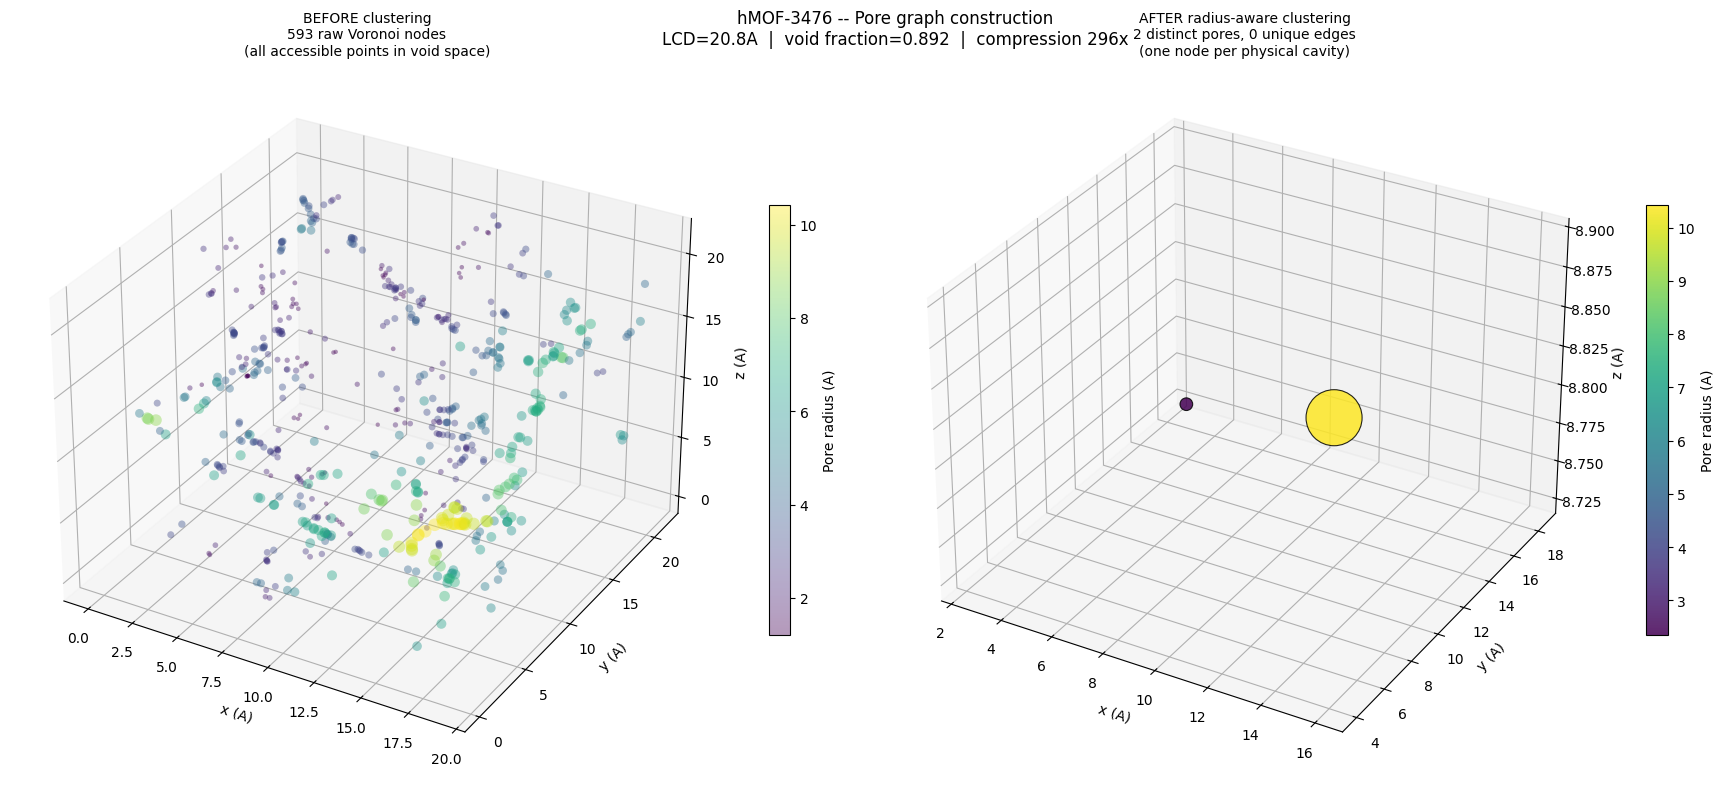

Saved to: /home/milan/Downloads/alignn/Thesis/Pore_plan_b/before_after_clustering.png


In [15]:
# Side-by-side 3D plot: before vs after
EDGE_CUTOFF = 8.0

# Build edges on clustered graph
D_clust = cdist(cluster_pos, cluster_pos)
src, dst = np.where((D_clust < EDGE_CUTOFF) & (D_clust > 0))

fig = plt.figure(figsize=(18, 8))

# LEFT: raw nodes 
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(
    positions[:, 0], positions[:, 1], positions[:, 2],
    s=radii * 8,
    c=radii,
    cmap='viridis',
    alpha=0.4,
    edgecolors='none'
)
ax1.set_xlabel('x (A)')
ax1.set_ylabel('y (A)')
ax1.set_zlabel('z (A)')
ax1.set_title(
    f'BEFORE clustering\n'
    f'{len(positions)} raw Voronoi nodes\n'
    f'(all accessible points in void space)',
    fontsize=10
)
plt.colorbar(sc1, ax=ax1, label='Pore radius (A)', shrink=0.6)

# RIGHT: clustered nodes
ax2 = fig.add_subplot(122, projection='3d')

# Draw edges first
seen = set()
for s, d in zip(src, dst):
    if (d, s) not in seen:
        seen.add((s, d))
        xs = [cluster_pos[s][0], cluster_pos[d][0]]
        ys = [cluster_pos[s][1], cluster_pos[d][1]]
        zs = [cluster_pos[s][2], cluster_pos[d][2]]
        ax2.plot(xs, ys, zs, color='gray', alpha=0.6, linewidth=1.5)

# Draw nodes
sc2 = ax2.scatter(
    cluster_pos[:, 0], cluster_pos[:, 1], cluster_pos[:, 2],
    s=cluster_rad ** 2 * 15,
    c=cluster_rad,
    cmap='viridis',
    alpha=0.85,
    edgecolors='black',
    linewidths=0.8,
    zorder=5
)

# Label each node with index, radius, and how many raw nodes it absorbed
for i, (pos, r, sz) in enumerate(zip(cluster_pos, cluster_rad, cluster_sizes)):
    ax2.text(
        pos[0]+0.3, pos[1]+0.3, pos[2]+0.3,
        f'{i}\n{r:.1f}A\n({sz} merged)',
        fontsize=7
    )

ax2.set_xlabel('x (A)')
ax2.set_ylabel('y (A)')
ax2.set_zlabel('z (A)')
ax2.set_title(
    f'AFTER radius-aware clustering\n'
    f'{len(cluster_pos)} distinct pores, {len(seen)} unique edges\n'
    f'(one node per physical cavity)',
    fontsize=10
)
plt.colorbar(sc2, ax=ax2, label='Pore radius (A)', shrink=0.6)

# Use raw[0] directly to always get hMOF-3476
entry0 = raw[0]
plt.suptitle(
    f'hMOF-3476 -- Pore graph construction\n'
    f'LCD={entry0["lcd"]:.1f}A  |  '
    f'void fraction={entry0["void_fraction"]:.3f}  |  '
    f'compression {len(positions)/len(cluster_pos):.0f}x',
    fontsize=12
)

plt.tight_layout()
save_path = '/home/milan/Downloads/alignn/Thesis/Pore_plan_b/before_after_clustering.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to: {save_path}')


## Bipartite atom–pore graph (supervisor's idea)


The pore-only graph a **graph** G where:

- **N₁** = atom nodes  (the same atoms as in ALIGNN's crystal graph)
- **N₂** = pore nodes  (the clusters from `radius_aware_clustering`)
- **Edges only cross between N₁ and N₂** -- never atom–atom, never pore–pore

only need edges that cross the two sets.

This is physically grounded: an atom gets an edge to a pore if it is part of
that pore's wall (its van der Waals surface contributes to defining the void).


### Node features

Atom nodes (N₁): from jarvis

Pore nodes (N₂)

Each pore node carries two scalar features: its radius (the widest point of that
cavity, in Å) and the number of raw Voronoi nodes that were merged into it
(a proxy for the pore's "volume" or spatial extent).

### Edge features

An edge is drawn from pore p to atom a when atom a is within the pore's sphere:

  dist(pore_center_p, atom_position_a) < pore_radius_p + atom_vdw_radius_a

This means: the atom's van der Waals surface overlaps with the void sphere,
so it physically contributes to the pore wall.

The edge carries one feature: the distance from the pore center to the atom.
This tells the GNN how deep inside the pore sphere the atom sits.

---

### What message passing would do

- **Atom → Pore:** each pore aggregates messages from its wall atoms.
  The pore embedding learns *what chemistry lines its walls* (is it a
  zinc cluster, an organic linker, a mix?).
- **Pore → Atom:** each atom gets a message from the void it borders.
  The atom embedding learns *whether it is exposed to a large or small pore*.


In [ ]:
# atom–pore graph
# Requires: cluster_pos, cluster_rad, cluster_sizes  (from radius_aware_clustering)
#           atoms, RADII  (from the earlier cells)

import numpy as np
import torch
import dgl
from scipy.spatial.distance import cdist
from collections import Counter

# Atom positions and per-atom vdW radii
atom_positions = np.array(atoms.cart_coords)                               # (N_atoms, 3)
atom_elements  = atoms.elements                                            # list of strings
atom_radii     = np.array([RADII.get(el, 1.5) for el in atom_elements])   # (N_atoms,)

N_atoms = len(atom_elements)
N_pores = len(cluster_pos)

# Filter artefact pores before doing anything
MIN_PORE_RADIUS = 1.2  # Å, same probe radius used in write_to_XYZ
keep          = cluster_rad >= MIN_PORE_RADIUS
cluster_pos   = cluster_pos[keep]
cluster_rad   = cluster_rad[keep]
cluster_sizes = [s for s, k in zip(cluster_sizes, keep) if k]
N_pores       = len(cluster_pos)
print(f'Pores after filtering R < {MIN_PORE_RADIUS} Å: {N_pores}')

# Edge criterion
# Pore p connects to atom a when the atom is within the pore sphere.
# For large pores: threshold = R_pore + R_vdW_atom  (physically exact)
# For small pores: enforce a minimum search radius of 5 A so that narrow-
#                  channel pores still find the atoms forming their walls.

MIN_SEARCH = 5.0  # Å

D_pa      = cdist(cluster_pos, atom_positions)                # (N_pores, N_atoms)
threshold = np.maximum(
    cluster_rad[:, None] + atom_radii[None, :],               # R_pore + R_vdW
    MIN_SEARCH                                                 # floor at 5 A
)

pore_src, atom_dst = np.where(D_pa < threshold)               # connected pairs
edge_distances     = D_pa[pore_src, atom_dst]                 # (n_edges,)

print(f'Atoms:  {N_atoms}')
print(f'Pores:  {N_pores}')
print(f'Bipartite edges: {len(pore_src)}')
print(f'Average wall atoms per pore: {len(pore_src) / N_pores:.1f}')
print()

for p in range(N_pores):
    mask     = pore_src == p
    wall_els = [atom_elements[a] for a in atom_dst[mask]]
    counts   = Counter(wall_els)
    print(f'  Pore {p:2d} (R={cluster_rad[p]:.2f} Å)  -->  '
          f'{mask.sum():3d} wall atoms:  {dict(counts)}')

Pores after filtering R < 1.2 Å: 2
Atoms:  123
Pores:  2
Bipartite edges: 17
Average wall atoms per pore: 8.5

  Pore  0 (R=10.42 Å)  -->   12 wall atoms:  {'O': 5, 'H': 7}
  Pore  1 (R=2.35 Å)  -->    5 wall atoms:  {'O': 2, 'H': 3}


In [ ]:
# Node features
# Atom node features: one-hot element encoding
# Use the 9 most common elements in hMOF; anything else maps to an "other" bucket.
ELEMENT_ORDER = ['H', 'C', 'N', 'O', 'F', 'S', 'Cl', 'Zn', 'Cu']
elem_to_idx   = {el: i for i, el in enumerate(ELEMENT_ORDER)}
n_elem_types  = len(ELEMENT_ORDER) + 1   # +1 for "other"

atom_onehot = np.zeros((N_atoms, n_elem_types), dtype=np.float32)
for i, el in enumerate(atom_elements):
    col = elem_to_idx.get(el, n_elem_types - 1)  # unknown element -> last column
    atom_onehot[i, col] = 1.0

# Pore node features: [pore_radius, cluster_size]
pore_features = np.stack([
    cluster_rad,
    np.array(cluster_sizes, dtype=np.float32),
], axis=1)                               # (N_pores, 2)

# Build DGL graph
# We add both directions so message passing can go atom→pore AND pore→atom.
G = dgl.heterograph(
    {
        ('pore', 'wall',     'atom'): (pore_src.tolist(), atom_dst.tolist()),
        ('atom', 'wall_rev', 'pore'): (atom_dst.tolist(), pore_src.tolist()),
    },
    num_nodes_dict={'atom': N_atoms, 'pore': N_pores},
)

# Assign node features
G.nodes['atom'].data['h'] = torch.tensor(atom_onehot,   dtype=torch.float32)
G.nodes['pore'].data['h'] = torch.tensor(pore_features, dtype=torch.float32)

# Assign edge features (same distance for both directions)
dist_tensor = torch.tensor(edge_distances, dtype=torch.float32).unsqueeze(1)
G.edges['wall'].data['d']     = dist_tensor
G.edges['wall_rev'].data['d'] = dist_tensor

print('DGL Heterogeneous Bipartite Graph G:')
print(G)
print()
print(f'Atom node feature shape:  {G.nodes["atom"].data["h"].shape}')
print(f'  -> {n_elem_types} columns: one-hot over {ELEMENT_ORDER} + other')
print(f'Pore node feature shape:  {G.nodes["pore"].data["h"].shape}')
print(f'  -> col 0 = pore radius (Å),  col 1 = merged Voronoi nodes')
print(f'Edge feature shape:       {G.edges["wall"].data["d"].shape}')
print(f'  -> pore-center to atom distance (Å)')


DGL Heterogeneous Bipartite Graph G:
Graph(num_nodes={'atom': 123, 'pore': 2},
      num_edges={('atom', 'wall_rev', 'pore'): 17, ('pore', 'wall', 'atom'): 17},
      metagraph=[('atom', 'pore', 'wall_rev'), ('pore', 'atom', 'wall')])

Atom node feature shape:  torch.Size([123, 10])
  -> 10 columns: one-hot over ['H', 'C', 'N', 'O', 'F', 'S', 'Cl', 'Zn', 'Cu'] + other
Pore node feature shape:  torch.Size([2, 2])
  -> col 0 = pore radius (Å),  col 1 = merged Voronoi nodes
Edge feature shape:       torch.Size([17, 1])
  -> pore-center to atom distance (Å)


/tmp/ipykernel_10253/883979068.py:44: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches = [mpatches.Patch(color=ELEM_COLORS.get(el, '#888888'), label=el,


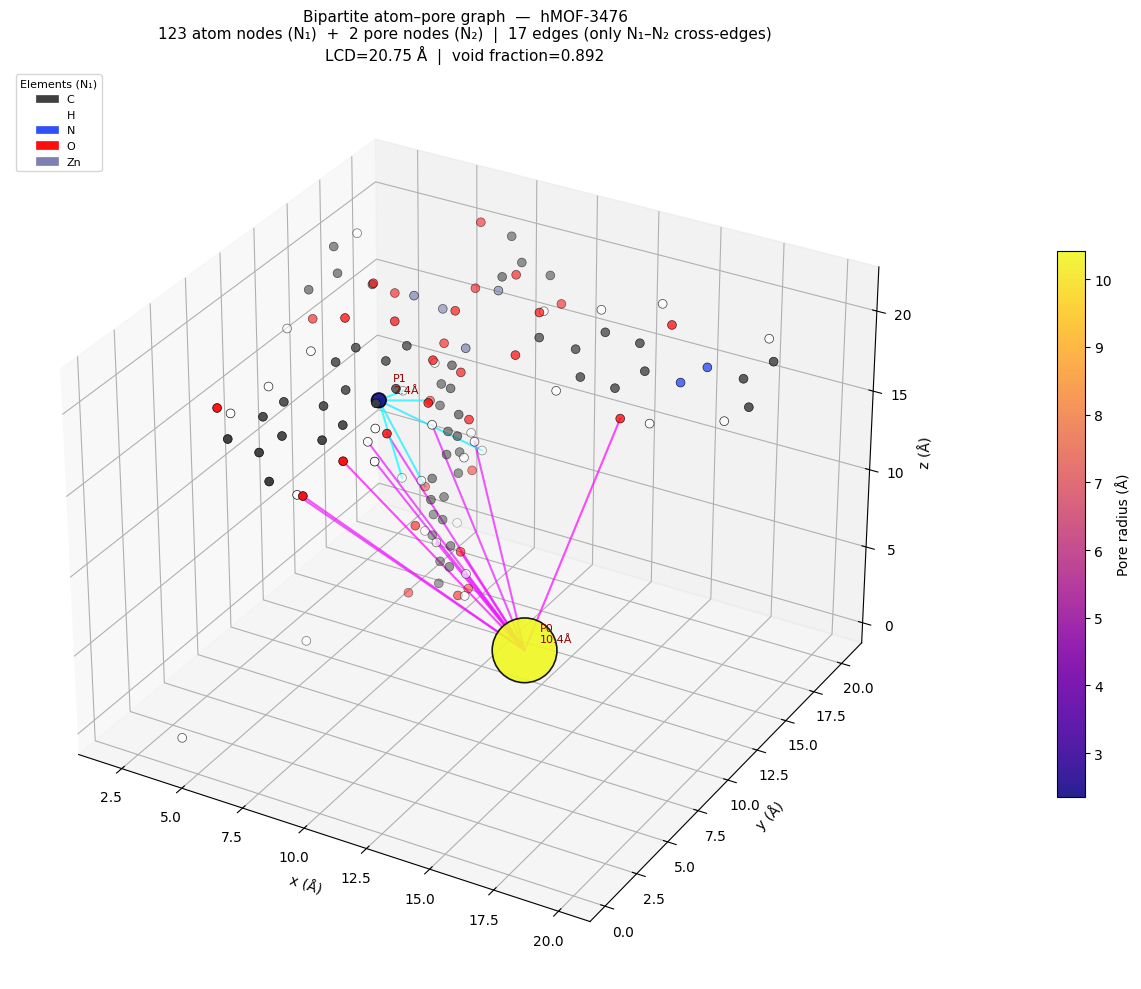

In [ ]:
# Visualise the pore node graph 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ELEM_COLORS = {
    'H': '#FFFFFF', 'C': '#404040', 'N': '#3050F8',
    'O': '#FF0D0D', 'F': '#90E050', 'S': '#FFFF30',
    'Cl': '#1FF01F', 'Zn': '#7D80B0', 'Cu': '#C88033',
}

fig = plt.figure(figsize=(14, 10))
ax  = fig.add_subplot(111, projection='3d')

# Draw edges (thicker, more opaque, coloured by distance) 
edge_norms = (edge_distances - edge_distances.min()) / (edge_distances.max() - edge_distances.min() + 1e-8)
for (p, a, norm) in zip(pore_src, atom_dst, edge_norms):
    xs = [cluster_pos[p][0], atom_positions[a][0]]
    ys = [cluster_pos[p][1], atom_positions[a][1]]
    zs = [cluster_pos[p][2], atom_positions[a][2]]
    ax.plot(xs, ys, zs, color=plt.cm.cool(norm), alpha=0.7, linewidth=1.5, zorder=2)

# Draw atom nodes 
atom_colors = [ELEM_COLORS.get(el, '#888888') for el in atom_elements]
ax.scatter(
    atom_positions[:, 0], atom_positions[:, 1], atom_positions[:, 2],
    s=40, c=atom_colors, edgecolors='black', linewidths=0.5, zorder=3,
)

# Draw pore nodes
sc = ax.scatter(
    cluster_pos[:, 0], cluster_pos[:, 1], cluster_pos[:, 2],
    s=cluster_rad ** 2 * 20, c=cluster_rad, cmap='plasma',
    edgecolors='black', linewidths=1.2, zorder=5, alpha=0.9,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label('Pore radius (Å)', fontsize=10)

for i, (pos, r) in enumerate(zip(cluster_pos, cluster_rad)):
    ax.text(pos[0]+0.4, pos[1]+0.4, pos[2]+0.4,
            f'P{i}\n{r:.1f}Å', fontsize=8, color='darkred', zorder=6)

present_elements = sorted(set(atom_elements))
patches = [mpatches.Patch(color=ELEM_COLORS.get(el, '#888888'), label=el,
                          edgecolor='black', linewidth=0.5)
           for el in present_elements]
ax.legend(handles=patches, title='Elements (N₁)',
          loc='upper left', fontsize=8, title_fontsize=8)

ax.set_xlabel('x (Å)')
ax.set_ylabel('y (Å)')
ax.set_zlabel('z (Å)')
ax.set_title(
    f'Bipartite atom–pore graph  —  {entry["id"]}\n'
    f'{N_atoms} atom nodes (N₁)  +  {N_pores} pore nodes (N₂)  |  '
    f'{len(pore_src)} edges (only N₁–N₂ cross-edges)\n'
    f'LCD={entry["lcd"]:.2f} Å  |  void fraction={entry["void_fraction"]:.3f}',
    fontsize=11,
)

plt.tight_layout()
save_path = '/home/milan/Downloads/alignn/Thesis/Pore_plan_b/bipartite_graph.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()